# TOPIC
# Course Name : MSc Business Analytics 
# Module Code : MN5813
# Module Tutor : Alex Reppel 
# Candidate Number: 2502850

 # Project Summary

# Introduction
This python assignment revolves around Covid-19, confirmed cases, recoveries, fatalities and vaccination rate around the world. At the other hand I have taken an employee data set. This project show how Covid-19 has affected the job market like leading to creation of new jobs and how the death rate has affected job market in the whole. 


# Objectives 
1. Covid-19 cases vs deaths
2. Attrition rate per department
3. Correlation Matrix of Covid-19

# Generative AI
Generative AI has been utilized in this report, specifically the basic version of ChatGPT. In many instances, I've modified the code and consulted my coursework as well. The link to the website is: https://chatgpt.com/




# Setup 

# Import the Libraries

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import the Dataset

In [65]:
# Load the dataset
covid_df = pd.read_csv('COVID-19 Global Statistics Dataset.csv')  # Updated file path
hr_data = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')  # Update if needed

# Display basic information

In [67]:
print(covid_df.info())
print(hr_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            239 non-null    object 
 1   Total Cases        239 non-null    object 
 2   New Cases          12 non-null     object 
 3   Total Deaths       234 non-null    object 
 4   New Deaths         7 non-null      float64
 5   Total Recovered    190 non-null    object 
 6   New Recovered      17 non-null     object 
 7   Active Cases       191 non-null    object 
 8   Serious, Critical  60 non-null     object 
 9   Tot Cases/1M pop   230 non-null    object 
 10  Deaths/1M pop      225 non-null    object 
 11  Total Tests        213 non-null    object 
 12  Tests/1M pop       213 non-null    object 
 13  Population         229 non-null    object 
dtypes: float64(1), object(13)
memory usage: 26.3+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to

# Cleans and prepares a DataFrame

In [69]:
numeric_columns = [
    "Total Cases", "New Cases", "Total Deaths", "New Deaths",
    "Total Recovered", "New Recovered", "Active Cases",
    "Serious, Critical", "Tot Cases/1M pop", "Deaths/1M pop",
    "Total Tests", "Tests/1M pop", "Population"
]
for column in numeric_columns:
    if column in covid_df.columns:  # Changed 'covid_data' to 'covid_df'
        covid_df[column] = (       # Changed 'covid_data' to 'covid_df'
            covid_df[column]       # Changed 'covid_data' to 'covid_df'
            .replace({',': ''}, regex=True)
            .apply(pd.to_numeric, errors='coerce')
        )

# Replace the missing values with zeros for simplicity.
covid_df.fillna(0, inplace=True)

# Drop redundant columns

In [75]:
redundant_columns = ["EmployeeCount", "Over18", "StandardHours"]
# Verify the existence of columns prior to removing them.
existing_columns = [col for col in redundant_columns if col in hr_data.columns]
hr_data.drop(columns=existing_columns, inplace=True)

# Standardize categorical columns
categorical_columns = hr_data.select_dtypes(include="object").columns
for column in categorical_columns:
    hr_data[column] = hr_data[column].str.strip().str.lower()


# Sum the total number of cases, death, and population figures for each country.

In [77]:
covid_summary = covid_df.groupby('Country')[['Total Cases', 'Total Deaths', 'Population']].sum().reset_index()

# Normalize cases and deaths by population
covid_summary['Cases per Million'] = (covid_summary['Total Cases'] / covid_summary['Population']) * 1e6
covid_summary['Deaths per Million'] = (covid_summary['Total Deaths'] / covid_summary['Population']) * 1e6

# Calculate attrition rate by department

In [79]:
# Check 'department' column is present; if it isn't, explore alternative names or examine the data loading process
if 'department' in hr_data.columns:
    attrition_summary = hr_data.groupby('department')['attrition'].value_counts(normalize=True).unstack()
elif 'Department' in hr_data.columns:
    attrition_summary = hr_data.groupby('Department')['Attrition'].value_counts(normalize=True).unstack() # Complete the statement in the elif block
    # If the name of the 'Attrition' column varies, make the necessary adjustments.

# Print cleaned COVID-19 dataset

In [81]:
print("Cleaned COVID-19 Dataset:")
print(covid_df.head())  # Display the first 5 rows
print("\nDataset Information:")
print(covid_df.info())  # Display dataset summary

Cleaned COVID-19 Dataset:
   Country  Total Cases  New Cases  Total Deaths  New Deaths  Total Recovered  \
0      USA    111367209        0.0     1199031.0         0.0      109053249.0   
1    India     45028429      161.0      533475.0         2.0              0.0   
2   France     40138560        0.0      167642.0         0.0       39970918.0   
3  Germany     38819284      574.0      182439.0        28.0       38240600.0   
4   Brazil     38407327        0.0      709765.0         0.0       36249161.0   

   New Recovered  Active Cases  Serious, Critical  Tot Cases/1M pop  \
0            0.0     1114929.0             1771.0          332633.0   
1            0.0           0.0                0.0           32012.0   
2            0.0           0.0                0.0          612013.0   
3            0.0      396245.0                0.0          462776.0   
4            0.0     1448401.0                0.0          178345.0   

   Deaths/1M pop   Total Tests  Tests/1M pop    Population  

# Print cleaned HR dataset

In [83]:
print("\nCleaned HR Dataset:")
print(hr_data.head())  # Display the first 5 rows
print("\nDataset Information:")
print(hr_data.info())  # Display dataset summary


Cleaned HR Dataset:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       yes      travel_rarely       1102                   sales   
1   49        no  travel_frequently        279  research & development   
2   37       yes      travel_rarely       1373  research & development   
3   33        no  travel_frequently       1392  research & development   
4   27        no      travel_rarely        591  research & development   

   DistanceFromHome  Education EducationField  EmployeeNumber  \
0                 1          2  life sciences               1   
1                 8          1  life sciences               2   
2                 2          2          other               4   
3                 3          4  life sciences               5   
4                 2          1        medical               7   

   EnvironmentSatisfaction  ... PerformanceRating  RelationshipSatisfaction  \
0                        2  ...                 3               

# 1. Grouping and Aggregation (COVID-19 Data): 

In [85]:
# Organize the data by country and compute the total number of cases, deaths, and the cases/deaths per million.
covid_summary = covid_df.groupby('Country')[['Total Cases', 'Total Deaths', 'Population']].sum().reset_index()
covid_summary['Cases per Million'] = (covid_summary['Total Cases'] / covid_summary['Population']) * 1e6
covid_summary['Deaths per Million'] = (covid_summary['Total Deaths'] / covid_summary['Population']) * 1e6

# 2. Combining Data Sources (Hypothetical)

In [87]:
# If we possessed external economic information for every country, we could combine it with covid_summary.
# To investigate possible relationships between economic variables and the effects of COVID-19.
# For this example, let's create a dummy economic indicator:
covid_summary['Economic Indicator'] = (covid_summary['Cases per Million'] / 1000) + (covid_summary['Deaths per Million'] / 10000)


# 3. Visualization (COVID-19 Data):

C:\Users\alisi\anaconda3\Lib\site-packages\matplotlib\colors.py:1371: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
C:\Users\alisi\anaconda3\Lib\site-packages\matplotlib\colors.py:1371: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


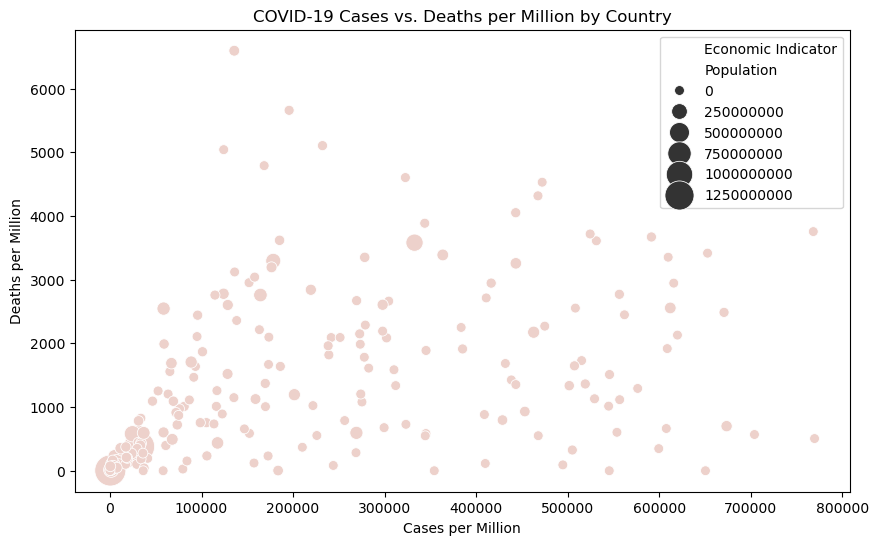

In [89]:
# Scatter plot to visualize the relationship between cases per million and deaths per million
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Cases per Million', y='Deaths per Million', data=covid_summary, hue='Economic Indicator', size='Population', sizes=(50, 500))
plt.title('COVID-19 Cases vs. Deaths per Million by Country')
plt.xlabel('Cases per Million')
plt.ylabel('Deaths per Million')
plt.show()


# 4. Grouping and Aggregation (HR Data):

In [91]:
# Group by department and calculate attrition rate
attrition_summary = hr_data.groupby('Department')['Attrition'].value_counts(normalize=True).unstack()

# 5. Visualization (HR Data):

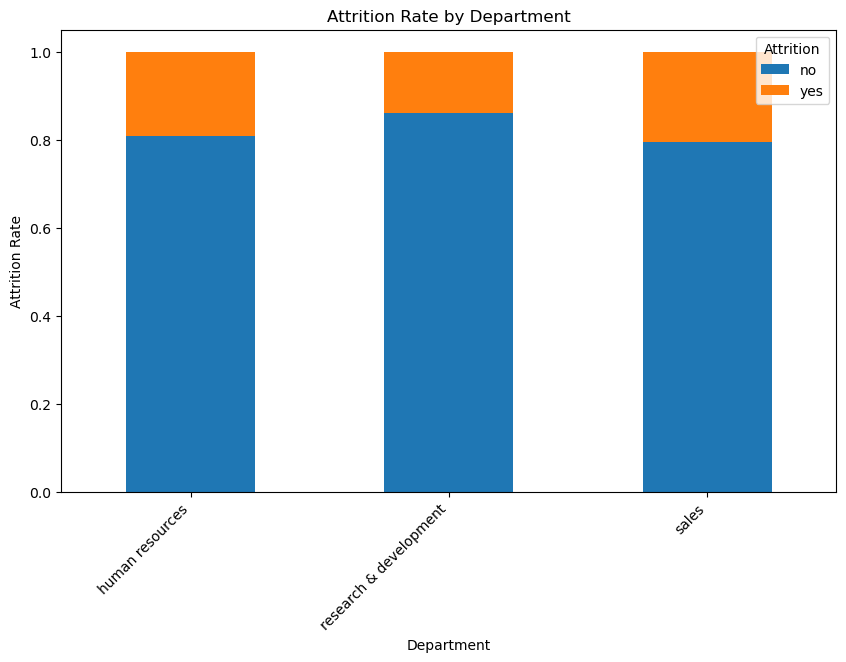

In [93]:
# Bar plot to visualize attrition rates by department
attrition_summary.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Attrition Rate')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Attrition')
plt.show()

# 6.Calculate the correlation matrix

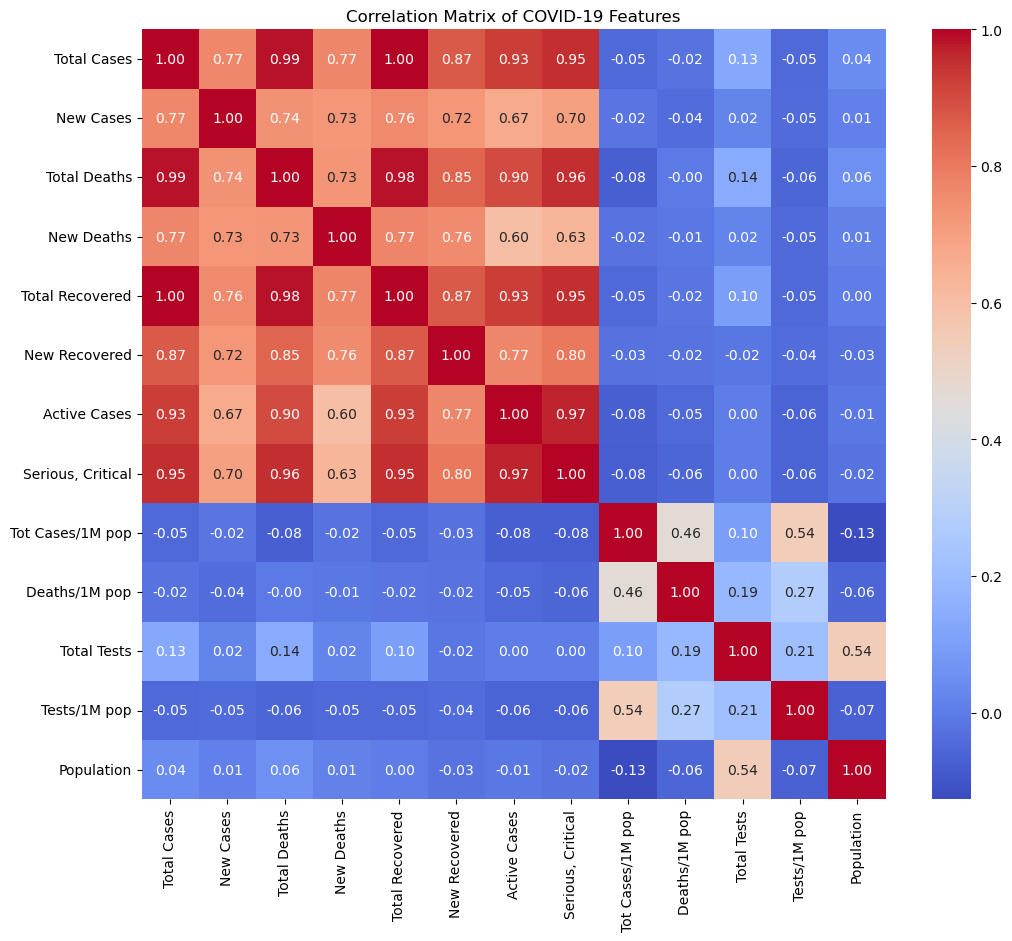

In [98]:
# Assuming 'covid_df' is your DataFrame
# Select numerical features for correlation analysis
numerical_features = ['Total Cases', 'New Cases', 'Total Deaths', 'New Deaths', 'Total Recovered', 
                     'New Recovered', 'Active Cases', 'Serious, Critical', 'Tot Cases/1M pop', 
                     'Deaths/1M pop', 'Total Tests', 'Tests/1M pop', 'Population']

# Calculate the correlation matrix
correlation_matrix = covid_df[numerical_features].corr()

# Create the heatmap
plt.figure(figsize=(12, 10))  # Adjust figure size if needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of COVID-19 Features')
plt.show()

In [101]:
# --- Download Cleaned Datasets ---
covid_df.to_csv('cleaned_covid_data.csv', index=False)
hr_data.to_csv('cleaned_hr_data.csv', index=False)

print("Cleaned datasets downloaded as 'cleaned_covid_data.csv' and 'cleaned_hr_data.csv'")

Cleaned datasets downloaded as 'cleaned_covid_data.csv' and 'cleaned_hr_data.csv'
